# Тема 4. Линейные модели

## Дополнительные материалы (самостоятельное чтение)

На занятии не разбираем. Три темы:

1. Откуда берётся функция потерь логистической регрессии (метод максимального правдоподобия)
2. Регуляризация полиномиальных признаков на классическом примере с круговой границей
3. Кривые обучения — ещё один диагностический инструмент, кроме кривых валидации

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

---
## 1. Откуда берётся функция потерь: метод максимального правдоподобия

На занятии сигмоида превращает линейную комбинацию признаков в вероятность класса 1: $\hat{p} = \sigma(w^Tx)$. Но откуда берётся то, что модель минимизирует — **log loss**, а не что-то ещё, например сумму квадратов ошибок, как в обычной регрессии?

**Идея метода максимального правдоподобия (MLE):** подберём коэффициенты $w$ так, чтобы вероятность **наблюдать именно те данные, которые у нас есть**, была максимальна. Для одного наблюдения с истинным классом $y \in \{0, 1\}$ и предсказанной вероятностью $\hat{p}$:

$$P(y \mid x) = \hat{p}^y (1 - \hat{p})^{1-y}$$

Для всей выборки (наблюдения независимы) вероятности перемножаются. Произведение неудобно оптимизировать (много сомножителей ∈ (0,1) → численно “взрывается” в очень маленькое число), поэтому максимизируют **логарифм** правдоподобия — а раз оптимизаторы в sklearn по соглашению **минимизируют**, берут его со знаком минус:

$$L = -\sum_i \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

Это и есть **log loss**. Штраф резко растёт, если модель уверенно (близко к 0 или 1) ошиблась — в этом смысле log loss «наказывает» самоуверенные ошибки сильнее, чем просто неточные предсказания около 0.5.

---
## 2. Регуляризация полиномиальных признаков: круговая граница

Классический пример, где линейная граница в исходных признаках не подходит вообще, но помогает **добавление полиномиальных признаков** ($x_1^2$, $x_1 x_2$, ...) — они превращают линейную модель в нелинейную по исходным $x_1, x_2$, оставляя её линейной по новым (расширенным) признакам.

Данные: результаты двух тестов микрочипов, `released` — прошёл ли контроль качества (область "хороших" чипов — примерно круг на плоскости двух тестов).

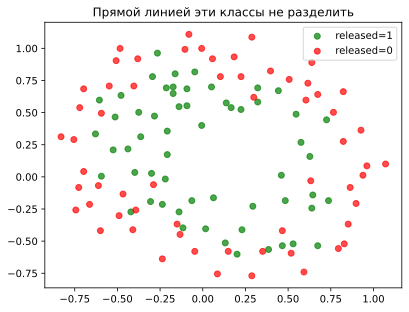

In [2]:
data = pd.read_csv("../data/microchip_tests.txt", header=None, names=["test1", "test2", "released"])
X = data[["test1", "test2"]].values
y = data["released"].values

plt.scatter(X[y == 1, 0], X[y == 1, 1], c="green", label="released=1", alpha=0.7)
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="red", label="released=0", alpha=0.7)
plt.legend()
plt.title("Прямой линией эти классы не разделить");

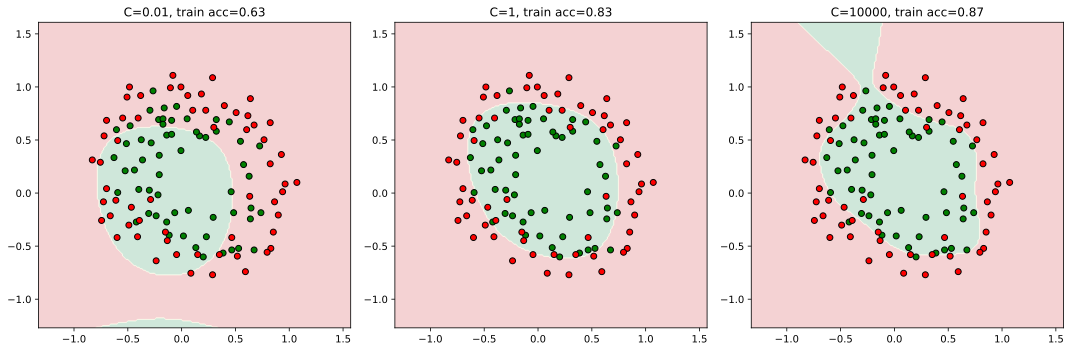

In [3]:
def plot_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.2, cmap="RdYlGn")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c="green", edgecolors="k")
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c="red", edgecolors="k")
    plt.title(title)

_, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, C in zip(axes, [0.01, 1, 10000]):
    plt.sca(ax)
    model = make_pipeline(PolynomialFeatures(7), LogisticRegression(C=C, max_iter=2000))
    model.fit(X, y)
    plot_boundary(model, X, y, f"C={C}, train acc={model.score(X, y):.2f}")
plt.tight_layout();

`C=0.01` (сильная регуляризация) — почти прямая линия, недообучение, круглую форму границы не улавливает. `C=1` — гладкая, близкая к кругу граница, похоже на разумный компромисс. `C=10000` (регуляризации почти нет) — граница подстраивается под каждую точку, переобучение, совсем как дерево неограниченной глубины или полином 15-й степени на занятии.

---
## 3. Кривые обучения

Кривая валидации (занятие) перебирает **гиперпараметр** при фиксированном размере данных. Кривая обучения перебирает **размер обучающей выборки** при фиксированной модели — отвечает на другой вопрос: «поможет ли модели больше данных?»

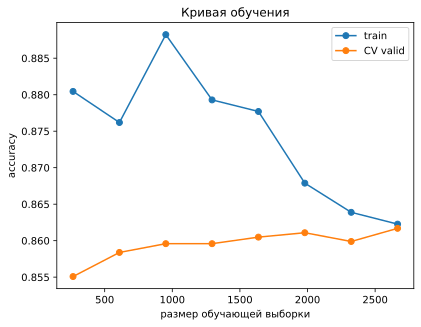

In [4]:
df = pd.read_csv("../data/telecom_churn.csv")
df["Churn"] = df["Churn"].astype(int)
df["International plan"] = (df["International plan"] == "Yes").astype(int)
df["Voice mail plan"] = (df["Voice mail plan"] == "Yes").astype(int)
X_churn = StandardScaler().fit_transform(df.drop(columns=["State", "Churn"]))
y_churn = df["Churn"]

train_sizes, train_scores, valid_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_churn, y_churn, cv=5, train_sizes=np.linspace(0.1, 1.0, 8),
)

plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="train")
plt.plot(train_sizes, valid_scores.mean(axis=1), marker="o", label="CV valid")
plt.xlabel("размер обучающей выборки")
plt.ylabel("accuracy")
plt.legend()
plt.title("Кривая обучения");

Valid-кривая почти плоская уже с небольшой доли данных — значит, узкое место не в объёме данных, а в **возможностях самой модели** (линейная граница просто не может выразить сложность зависимости лучше). Если бы valid-кривая продолжала расти с ростом данных — стоило бы держать это в уме перед тем, как усложнять модель — сначала попробовать собрать больше данных, это часто дешевле.

Как всегда, если бы train и valid кривые расходились сильно и не сходились — это был бы признак переобучения (высокий разброс, *variance*); если бы обе кривые были одинаково низкими — недообучения (высокое смещение, *bias*).

---
## Ещё одна тема (не входит сюда без доп. данных)

В оригинальном курсе mlcourse.ai здесь разбирается анализ тональности отзывов IMDB (логистическая регрессия на текстах, представленных через мешок слов). Мы не включаем это в наш курс — понадобится либо своя текстовая задача, либо тема 6 (конструирование признаков из текста, Bag of Words/TF-IDF), после которой такой пример будет к месту.

---
## Итог

Дальше — `lesson05...` (ансамблевые методы и случайный лес).